# ResViT FusionNet - APTOS 2019

Fusion notebook built from the CNN/ResNet50 and ViT-B/32 notebooks. The model follows the paper setup conceptually: ResNet50 and ViT are used as pretrained feature extractors, selected deeper layers are unfrozen, and their features are concatenated before final classification.

# Import & Setup

In [1]:
!pip install torchinfo

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 23.3.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms
from torchvision import models
from torchinfo import summary

from torch.utils.data import Dataset, DataLoader
from PIL import Image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import random
import sys

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# =========================
# GPU CHECK
# =========================
print("CUDA Available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

print("PyTorch Version:", torch.__version__)
print("CUDA Version:", torch.version.cuda)
print("Python Version:", sys.version)

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA Available: True
Number of GPUs: 1
GPU Name: Tesla V100-SXM2-32GB
PyTorch Version: 2.2.0a0+81ea7a4
CUDA Version: 12.3
Python Version: 3.10.12 (main, Nov 20 2023, 15:14:05) [GCC 11.4.0]
Using device: cuda


In [3]:
# =========================
# CONFIG
# =========================
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100
LR = 5e-4
NUM_CLASSES = 5
SEED = 42

In [4]:
# =========================
# SEED
# =========================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load Data (APTOS)

In [5]:
# =========================
# BASE DIRECTORY - KAGGLE
# =========================
INPUT_DIR = "/data/dataset"
WORKING_DIR = "/data/working"

# =========================
# DATASET PATH
# =========================
TRAIN_CSV = f"{INPUT_DIR}/train.csv"
TRAIN_IMAGE_DIR = f"{INPUT_DIR}/train_images"

# =========================
# OUTPUT PATH
# =========================
OUTPUT_DIR = f"{WORKING_DIR}/outputs"
MODEL_DIR = f"{OUTPUT_DIR}/models"
CHECKPOINT_DIR = f"{OUTPUT_DIR}/checkpoints"

# =========================
# CREATE FOLDER IF NOT EXIST
# =========================
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# =========================
# CHECK PATH
# =========================
print("TRAIN_CSV:", TRAIN_CSV)
print("TRAIN_IMAGE_DIR:", TRAIN_IMAGE_DIR)

print("Output folders created:")
print(OUTPUT_DIR)
print(MODEL_DIR)
print(CHECKPOINT_DIR)

TRAIN_CSV: /data/dataset/train.csv
TRAIN_IMAGE_DIR: /data/dataset/train_images
Output folders created:
/data/working/outputs
/data/working/outputs/models
/data/working/outputs/checkpoints


In [6]:
# =========================
# LOAD CSV
# =========================
train_df = pd.read_csv(TRAIN_CSV)

# =========================
# UPDATE FILE NAME
# =========================
train_df['id_code'] = train_df['id_code'].astype(str) + ".png"

# =========================
# LABEL
# =========================
train_df['diagnosis'] = train_df['diagnosis'].astype(int)

# =========================
# SHOW DATA
# =========================
print(train_df.head())

print("Class Distribution:")
print(train_df['diagnosis'].value_counts())

            id_code  diagnosis
0  000c1434d8d7.png          2
1  001639a390f0.png          4
2  0024cdab0c1e.png          1
3  002c21358ce6.png          0
4  005b95c28852.png          0
Class Distribution:
0    1805
2     999
1     370
4     295
3     193
Name: diagnosis, dtype: int64


# Split

In [7]:
# =========================
# TRAIN / VALIDATION SPLIT
# 80% train
# 10% validation
# 10% test
# =========================
val_size = 0.10 / (1 - 0.10)

train_data, test_data = train_test_split(
    train_df,
    test_size=0.10,
    stratify=train_df['diagnosis'],
    random_state=SEED)

train_data, val_data = train_test_split(
    train_data,
    test_size=val_size,
    stratify=train_data['diagnosis'],
    random_state=SEED)

# =========================
# RESET INDEX
# =========================
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

In [8]:
# =========================
# DATA SPLIT SUMMARY
# =========================
data_split = pd.DataFrame({
    'Set': ['Train', 'Validation', 'Test'],
    'Count': [len(train_data), len(val_data), len(test_data)]
})

data_split['Percentage (%)'] = (
    data_split['Count'] /
    data_split['Count'].sum()
) * 100

print(data_split)

          Set  Count  Percentage (%)
0       Train   2928       79.956308
1  Validation    367       10.021846
2        Test    367       10.021846


In [10]:
# =========================
# CLASS DISTRIBUTION
# =========================
def show_distribution(df, name):
    dist = df['diagnosis'].value_counts().sort_index()
    percent = (dist / len(df)) * 100

    result = pd.DataFrame({
        'Count': dist,
        'Percentage (%)': percent.round(2)
    })

    print(f"{name}")
    print(result)

show_distribution(train_data, "Train Data")
show_distribution(val_data, "Validation Data")
show_distribution(test_data, "Test Data")

Train Data
   Count  Percentage (%)
0   1443           49.28
1    296           10.11
2    799           27.29
3    155            5.29
4    235            8.03
Validation Data
   Count  Percentage (%)
0    181           49.32
1     37           10.08
2    100           27.25
3     19            5.18
4     30            8.17
Test Data
   Count  Percentage (%)
0    181           49.32
1     37           10.08
2    100           27.25
3     19            5.18
4     30            8.17


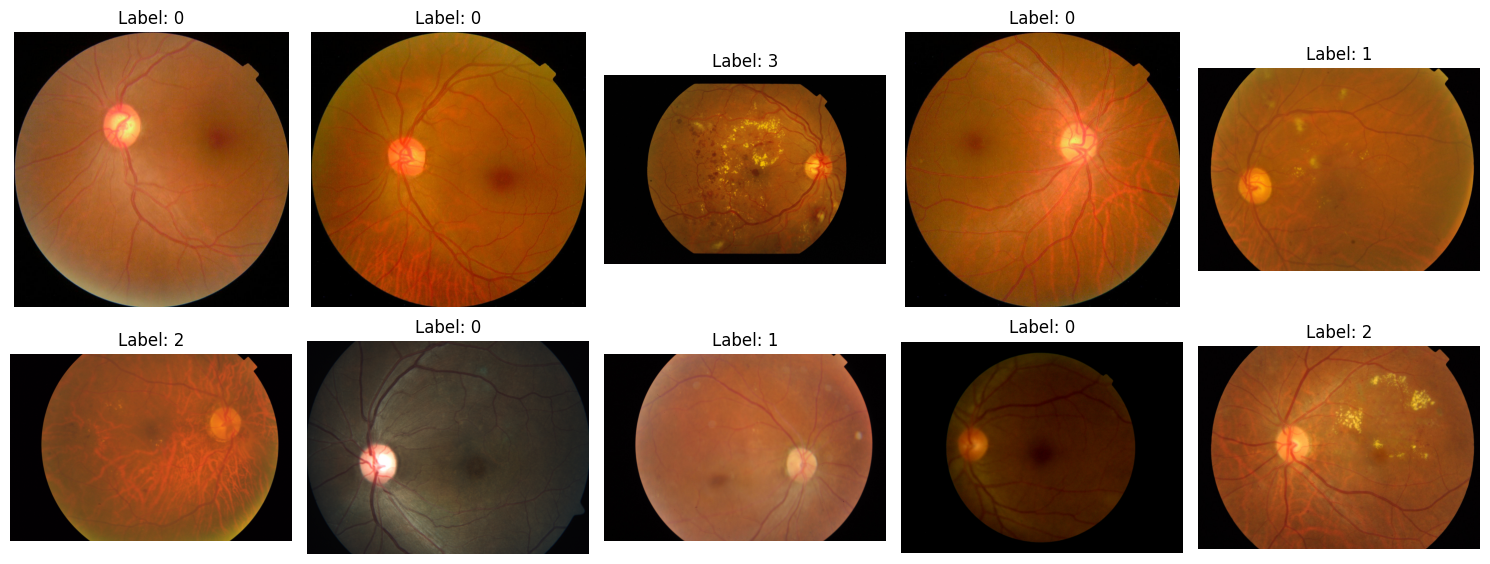

In [11]:
# =========================
# VISUALIZE SAMPLE IMAGES
# =========================
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img_path = os.path.join(TRAIN_IMAGE_DIR, train_data['id_code'].iloc[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {train_data['diagnosis'].iloc[i]}")

plt.tight_layout()
plt.show()

In [12]:
# =========================
# CHECK IMAGE RESOLUTIONS
# =========================
resolutions = []

for filename in os.listdir(TRAIN_IMAGE_DIR):
    img_path = os.path.join(TRAIN_IMAGE_DIR, filename)
    img = cv2.imread(img_path)
    if img is not None:
        h, w, _ = img.shape
        resolutions.append((h, w))

counter = Counter(resolutions)
total = sum(counter.values())
data = []

for (h, w), count in counter.items():
    percentage = (count / total) * 100
    data.append([f"{h}x{w}", count, round(percentage, 2)])

df_size = pd.DataFrame(
    data,
    columns=["Resolution (HxW)", "Number of Images", "Percentage"])

df_size = df_size.sort_values(
    by="Number of Images",
    ascending=False).reset_index(drop=True)

df_size

,Resolution (HxW),Number of Images,Percentage
0,1050x1050,974,26.60
1,1736x2416,638,17.42
2,1958x2588,533,14.55
3,2136x3216,410,11.20
4,1536x2048,351,9.58
5,614x819,287,7.84
6,2588x3388,141,3.85
7,1000x1504,92,2.51
8,1226x1844,61,1.67
9,2848x4288,52,1.42


# Train and Validation Generator

In [13]:
# =========================
# DATA PREPROCESSING
# & AUGMENTATION
# =========================
vit_weights = models.ViT_B_32_Weights.IMAGENET1K_V1
resnet_weights = models.ResNet50_Weights.IMAGENET1K_V1

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.85, 1.15)
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [14]:
# =========================
# CUSTOM DATASET
# =========================
class RetinaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, "id_code"]
        label = int(self.dataframe.loc[idx, "diagnosis"])
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
# =========================
# DATASETS
# =========================
train_dataset = RetinaDataset(
    dataframe=train_data,
    image_dir=TRAIN_IMAGE_DIR,
    transform=train_transform)

val_dataset = RetinaDataset(
    dataframe=val_data,
    image_dir=TRAIN_IMAGE_DIR,
    transform=val_transform)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 2928
Validation dataset: 367


In [16]:
# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

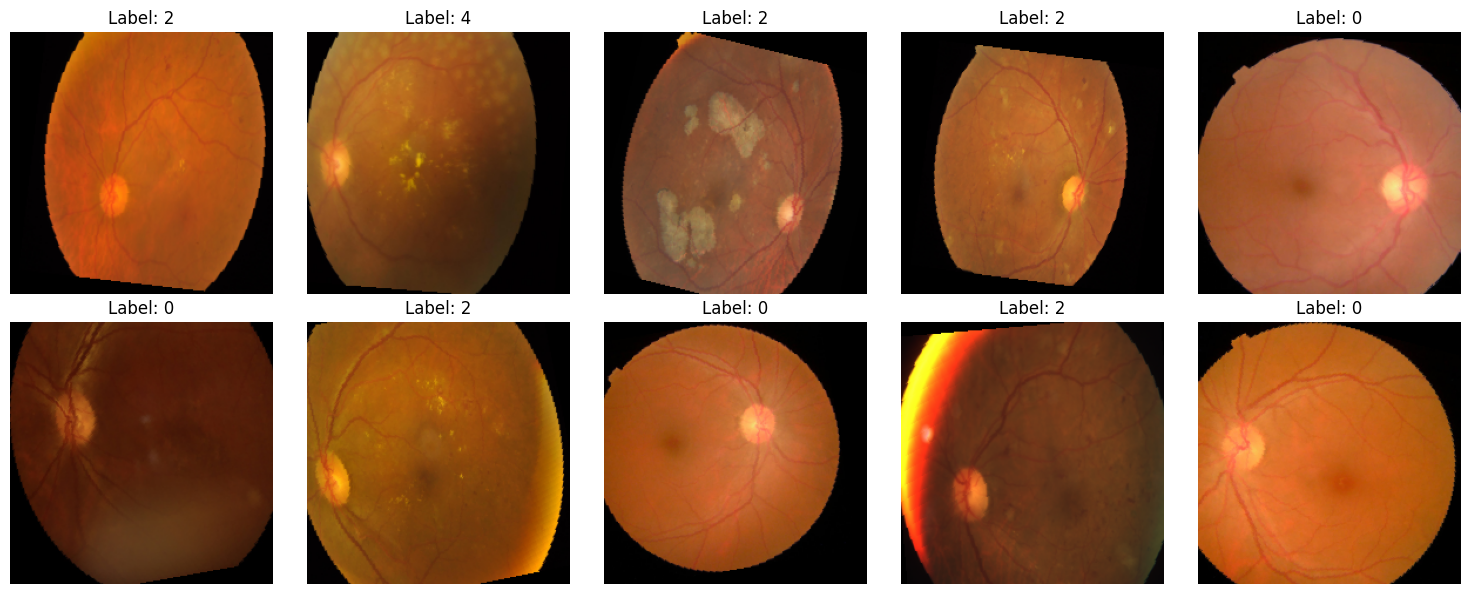

In [17]:
# =========================
# VISUALIZE AUGMENTED IMAGES
# =========================
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
images, labels = next(iter(train_loader))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {labels[i].item()}")

plt.tight_layout()
plt.show()

# ResViT FusionNet Model Build

In [18]:
# =========================
# HYBRID RESNET50 + ViT-B/32
# =========================
class ResViTFusionNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Load pretrained ResNet50 as feature extractor
        self.resnet50 = models.resnet50(weights=resnet_weights)
        resnet_features = self.resnet50.fc.in_features
        self.resnet50.fc = nn.Identity()

        # Load pretrained ViT-B/32 as feature extractor
        self.vit = models.vit_b_32(weights=vit_weights)
        vit_features = self.vit.heads.head.in_features
        self.vit.heads.head = nn.Identity()

        # Combine ResNet and ViT features
        self.fc_combined = nn.Linear(
            resnet_features + vit_features,
            num_classes)

    def forward(self, x):
        resnet_features = self.resnet50(x)
        vit_features = self.vit(x)
        combined_features = torch.cat(
            (resnet_features, vit_features),
            dim=1)
        output = self.fc_combined(combined_features)
        return output


model = ResViTFusionNet(num_classes=NUM_CLASSES)

# =========================
# FREEZE ALL LAYERS
# =========================
for param in model.resnet50.parameters():
    param.requires_grad = False

for param in model.vit.parameters():
    param.requires_grad = False

# =========================
# UNFREEZE PAPER-STYLE FINE-TUNING LAYERS
# ResNet50: layer4
# ViT torchvision equivalent of model.vit.blocks[-10:]
# =========================
for param in model.resnet50.layer4.parameters():
    param.requires_grad = True

for param in model.vit.encoder.layers[-10:].parameters():
    param.requires_grad = True

for param in model.fc_combined.parameters():
    param.requires_grad = True

# =========================
# MOVE MODEL TO DEVICE
# =========================
model = model.to(device)

# =========================
# MODEL SUMMARY
# =========================
summary(
    model,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    col_names=["output_size", "num_params", "trainable"],
    depth=4)

Layer (type:depth-idx)                             Output Shape              Param #                   Trainable
ResViTFusionNet                                    [1, 5]                    --                        Partial
├─ResNet: 1-1                                      [1, 2048]                 --                        Partial
│    └─Conv2d: 2-1                                 [1, 64, 112, 112]         (9,408)                   False
│    └─BatchNorm2d: 2-2                            [1, 64, 112, 112]         (128)                     False
│    └─ReLU: 2-3                                   [1, 64, 112, 112]         --                        --
│    └─MaxPool2d: 2-4                              [1, 64, 56, 56]           --                        --
│    └─Sequential: 2-5                             [1, 256, 56, 56]          --                        False
│    │    └─Bottleneck: 3-1                        [1, 256, 56, 56]          --                        False
│    │    │    └─

In [19]:
# =========================
# TRAINABLE PARAMETER CHECK
# =========================
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total params:", f"{total_params:,}")
print("Trainable params:", f"{trainable_params:,}")
print("Non-trainable params:", f"{total_params - trainable_params:,}")

Total params: 110,977,349
Trainable params: 85,857,541
Non-trainable params: 25,119,808


# Training Setup

In [20]:
# =========================
# LOSS FUNCTION
# =========================
criterion = nn.CrossEntropyLoss()

# =========================
# OPTIMIZER
# =========================
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR)

# =========================
# LEARNING RATE SCHEDULER
# =========================
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1,
    gamma=0.7)

In [21]:
# =========================
# EARLY STOPPING
# =========================
class EarlyStopping:
    def __init__(
        self,
        patience=10,
        verbose=True,
        path=f"{CHECKPOINT_DIR}/best_resvit_fusionnet.pth"):

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print("Validation loss improved -> model saved")
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


early_stopping = EarlyStopping(
    patience=10,
    verbose=True)

# Training Loop

In [22]:
# =========================
# TRAINING LOOP
# =========================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []}

for epoch in range(EPOCHS):
    # =========================
    # TRAINING
    # =========================
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # =========================
    # VALIDATION
    # =========================
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

Epoch [1/100] | LR: 0.000350 | Train Loss: 0.7124 | Train Acc: 0.7367 | Val Loss: 0.6318 | Val Acc: 0.7602
Validation loss improved -> model saved
Epoch [2/100] | LR: 0.000245 | Train Loss: 0.5380 | Train Acc: 0.8009 | Val Loss: 0.5469 | Val Acc: 0.8065
Validation loss improved -> model saved
Epoch [3/100] | LR: 0.000171 | Train Loss: 0.4950 | Train Acc: 0.8101 | Val Loss: 0.5752 | Val Acc: 0.7793
EarlyStopping counter: 1/10
Epoch [4/100] | LR: 0.000120 | Train Loss: 0.4230 | Train Acc: 0.8395 | Val Loss: 0.5810 | Val Acc: 0.8147
EarlyStopping counter: 2/10
Epoch [5/100] | LR: 0.000084 | Train Loss: 0.3955 | Train Acc: 0.8521 | Val Loss: 0.5485 | Val Acc: 0.8093
EarlyStopping counter: 3/10
Epoch [6/100] | LR: 0.000059 | Train Loss: 0.3648 | Train Acc: 0.8685 | Val Loss: 0.5018 | Val Acc: 0.8202
Validation loss improved -> model saved
Epoch [7/100] | LR: 0.000041 | Train Loss: 0.3353 | Train Acc: 0.8726 | Val Loss: 0.4808 | Val Acc: 0.8365
Validation loss improved -> model saved
Epoch [

# Validation Evaluation

In [23]:
# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(
    torch.load(f"{CHECKPOINT_DIR}/best_resvit_fusionnet.pth"))
model = model.to(device)
model.eval()
print("Best model loaded.")

Best model loaded.


In [24]:
# =========================
# VALIDATION EVALUATION
# =========================
y_true = []
y_pred = []
pred_probs = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        pred_probs.extend(probs.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

pred_probs = np.array(pred_probs)
y_pred = np.array(y_pred)
y_true = np.array(y_true)
class_names = [str(i) for i in range(NUM_CLASSES)]

print("Prediction shape:", pred_probs.shape)
print("Number of predictions:", len(y_pred))

Prediction shape: (367, 5)
Number of predictions: 367


In [27]:
# =========================
# ACCURACY, REPORT, CONFUSION MATRIX
# =========================
acc = accuracy_score(y_true, y_pred)
print(f"Validation Accuracy: {acc:.4f}")

print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Validation Accuracy: 0.8365
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       181
           1       0.67      0.70      0.68        37
           2       0.73      0.89      0.80       100
           3       0.55      0.32      0.40        19
           4       0.77      0.33      0.47        30

    accuracy                           0.84       367
   macro avg       0.74      0.64      0.66       367
weighted avg       0.83      0.84      0.82       367

Confusion Matrix:
[[176   5   0   0   0]
 [  4  26   7   0   0]
 [  2   5  89   2   2]
 [  0   1  11   6   1]
 [  0   2  15   3  10]]


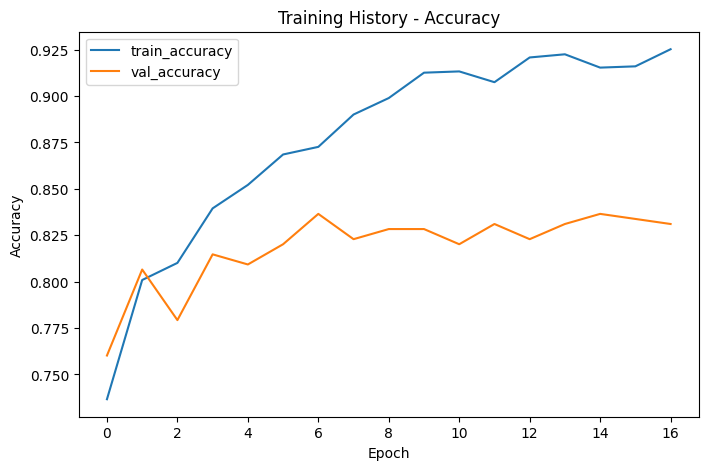

In [28]:
# =========================
# TRAINING HISTORY - ACCURACY
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="train_accuracy")
plt.plot(history["val_acc"], label="val_accuracy")
plt.title("Training History - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

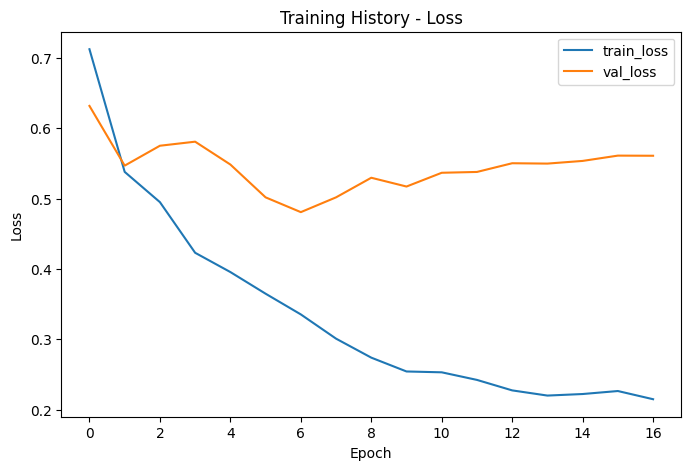

In [29]:
# =========================
# TRAINING HISTORY - LOSS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Training History - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [30]:
# =========================
# SAVE FINAL MODEL
# =========================
FINAL_MODEL_PATH = f"{MODEL_DIR}/resvit_fusionnet_aptos.pth"

torch.save(model.state_dict(), FINAL_MODEL_PATH)
print(f"Model saved to: {FINAL_MODEL_PATH}")

Model saved to: /data/working/outputs/models/resvit_fusionnet_aptos.pth


# Holdout Test Data

In [31]:
# =========================
# TEST DATASET AND DATALOADER
# =========================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_dataset = RetinaDataset(
    dataframe=test_data,
    image_dir=TRAIN_IMAGE_DIR,
    transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

In [32]:
# =========================
# EVALUATE ON HOLD-OUT TEST SET
# =========================
model.eval()
holdout_test_predictions = []
holdout_test_true_labels = []
holdout_test_pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        holdout_test_predictions.extend(probs.cpu().numpy())
        holdout_test_true_labels.extend(labels.cpu().numpy())
        holdout_test_pred_labels.extend(predicted.cpu().numpy())

holdout_test_predictions = np.array(holdout_test_predictions)
holdout_test_true_labels = np.array(holdout_test_true_labels)
holdout_test_pred_labels = np.array(holdout_test_pred_labels)

print("Prediction shape:", holdout_test_predictions.shape)
print("Number of predictions:", len(holdout_test_pred_labels))

Prediction shape: (367, 5)
Number of predictions: 367


In [34]:
# =========================
# TEST METRICS
# =========================
conf_matrix = confusion_matrix(
    holdout_test_true_labels,
    holdout_test_pred_labels)

print("Confusion Matrix:")
print(conf_matrix)

class_report = classification_report(
    holdout_test_true_labels,
    holdout_test_pred_labels)

print("Classification Report:")
print(class_report)

Confusion Matrix:
[[178   2   1   0   0]
 [  3  21  13   0   0]
 [  0   8  89   2   1]
 [  0   1  10   5   3]
 [  0   0  14   2  14]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       181
           1       0.66      0.57      0.61        37
           2       0.70      0.89      0.78       100
           3       0.56      0.26      0.36        19
           4       0.78      0.47      0.58        30

    accuracy                           0.84       367
   macro avg       0.73      0.63      0.66       367
weighted avg       0.83      0.84      0.83       367



# Grad-CAM

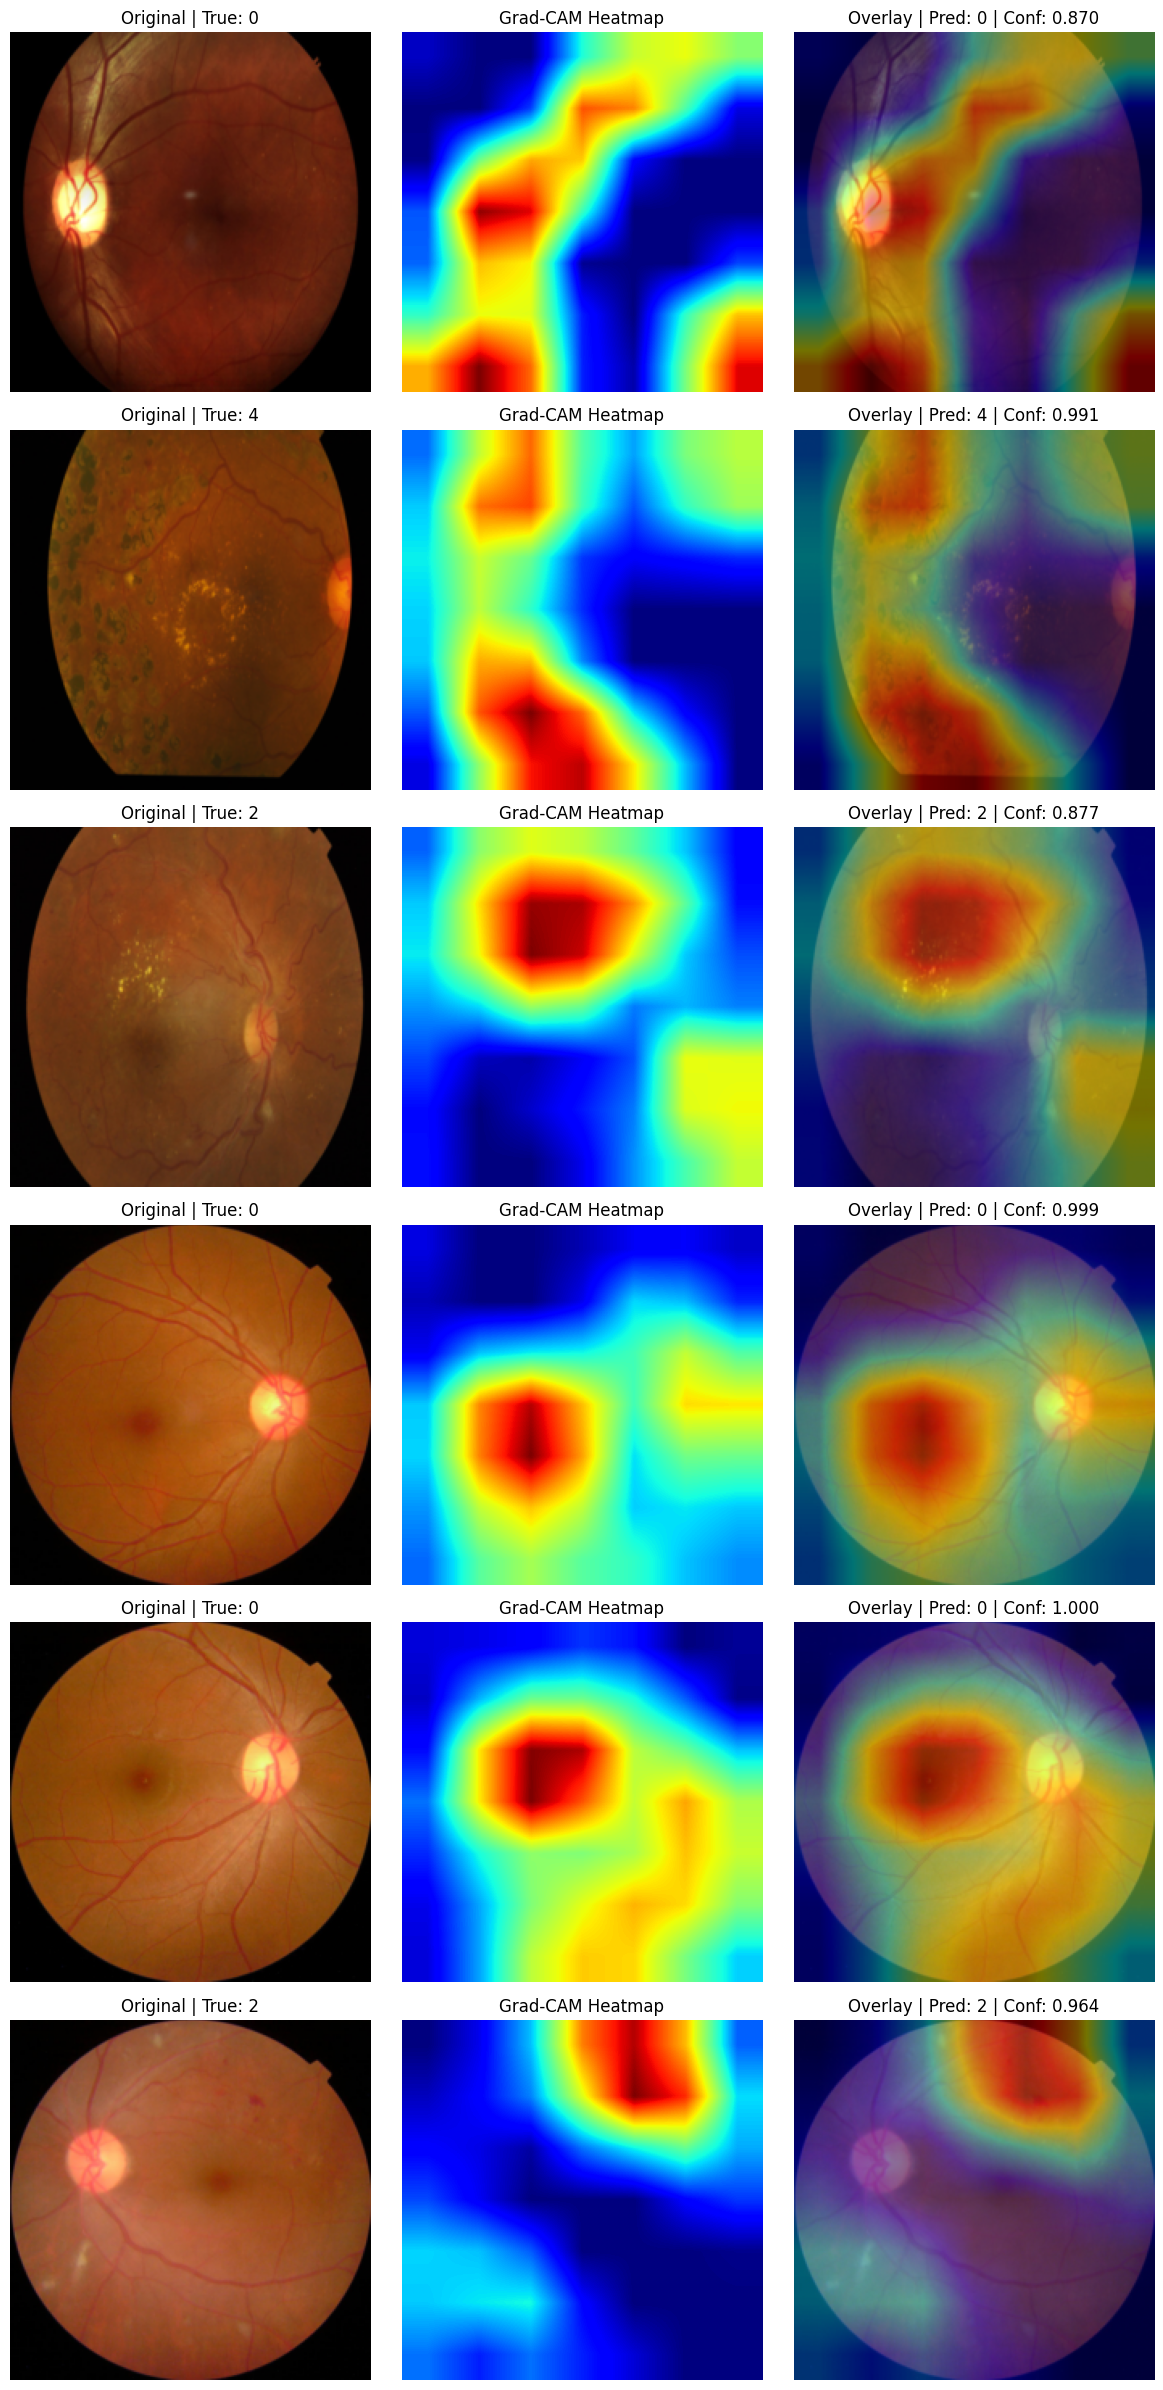

In [35]:
# =========================
# GRAD-CAM ON RESNET50 BRANCH
# =========================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.forward_handle = self.target_layer.register_forward_hook(
            self._save_activations)

    def _save_activations(self, module, input, output):
        self.activations = output
        output.register_hook(self._save_gradients)

    def _save_gradients(self, gradient):
        self.gradients = gradient.detach()

    def __call__(self, image_tensor, target_class=None):
        self.model.eval()
        image_tensor = image_tensor.to(device)

        self.model.zero_grad()
        output = self.model(image_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        score = output[:, target_class]
        score.backward()

        activations = self.activations.detach()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(
            cam,
            size=(IMG_SIZE, IMG_SIZE),
            mode='bilinear',
            align_corners=False)

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        probabilities = torch.softmax(output, dim=1).detach().cpu().numpy()[0]

        return cam, target_class, probabilities

    def remove_hooks(self):
        self.forward_handle.remove()


def tensor_to_image(image_tensor):
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = np.clip(image, 0, 1)
    return image


def overlay_gradcam(image, cam, alpha=0.45, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = (1 - alpha) * image + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)
    return overlay


def show_gradcam_samples(dataset, sample_indices=None, n_samples=6):
    if sample_indices is None:
        sample_indices = np.random.choice(
            len(dataset),
            size=n_samples,
            replace=False)

    grad_cam = GradCAM(
        model=model,
        target_layer=model.resnet50.layer4[-1])

    fig, axes = plt.subplots(
        len(sample_indices),
        3,
        figsize=(12, 4 * len(sample_indices)))

    if len(sample_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(sample_indices):
        image_tensor, true_label = dataset[idx]
        input_tensor = image_tensor.unsqueeze(0)

        cam, pred_label, probabilities = grad_cam(input_tensor)
        image = tensor_to_image(image_tensor)
        overlay = overlay_gradcam(image, cam)
        confidence = probabilities[pred_label]

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f"Original | True: {true_label}")
        axes[row, 0].axis('off')

        axes[row, 1].imshow(cam, cmap='jet')
        axes[row, 1].set_title("Grad-CAM Heatmap")
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(
            f"Overlay | Pred: {pred_label} | Conf: {confidence:.3f}")
        axes[row, 2].axis('off')

    grad_cam.remove_hooks()
    plt.tight_layout()
    plt.show()


show_gradcam_samples(
    dataset=val_dataset,
    n_samples=6)

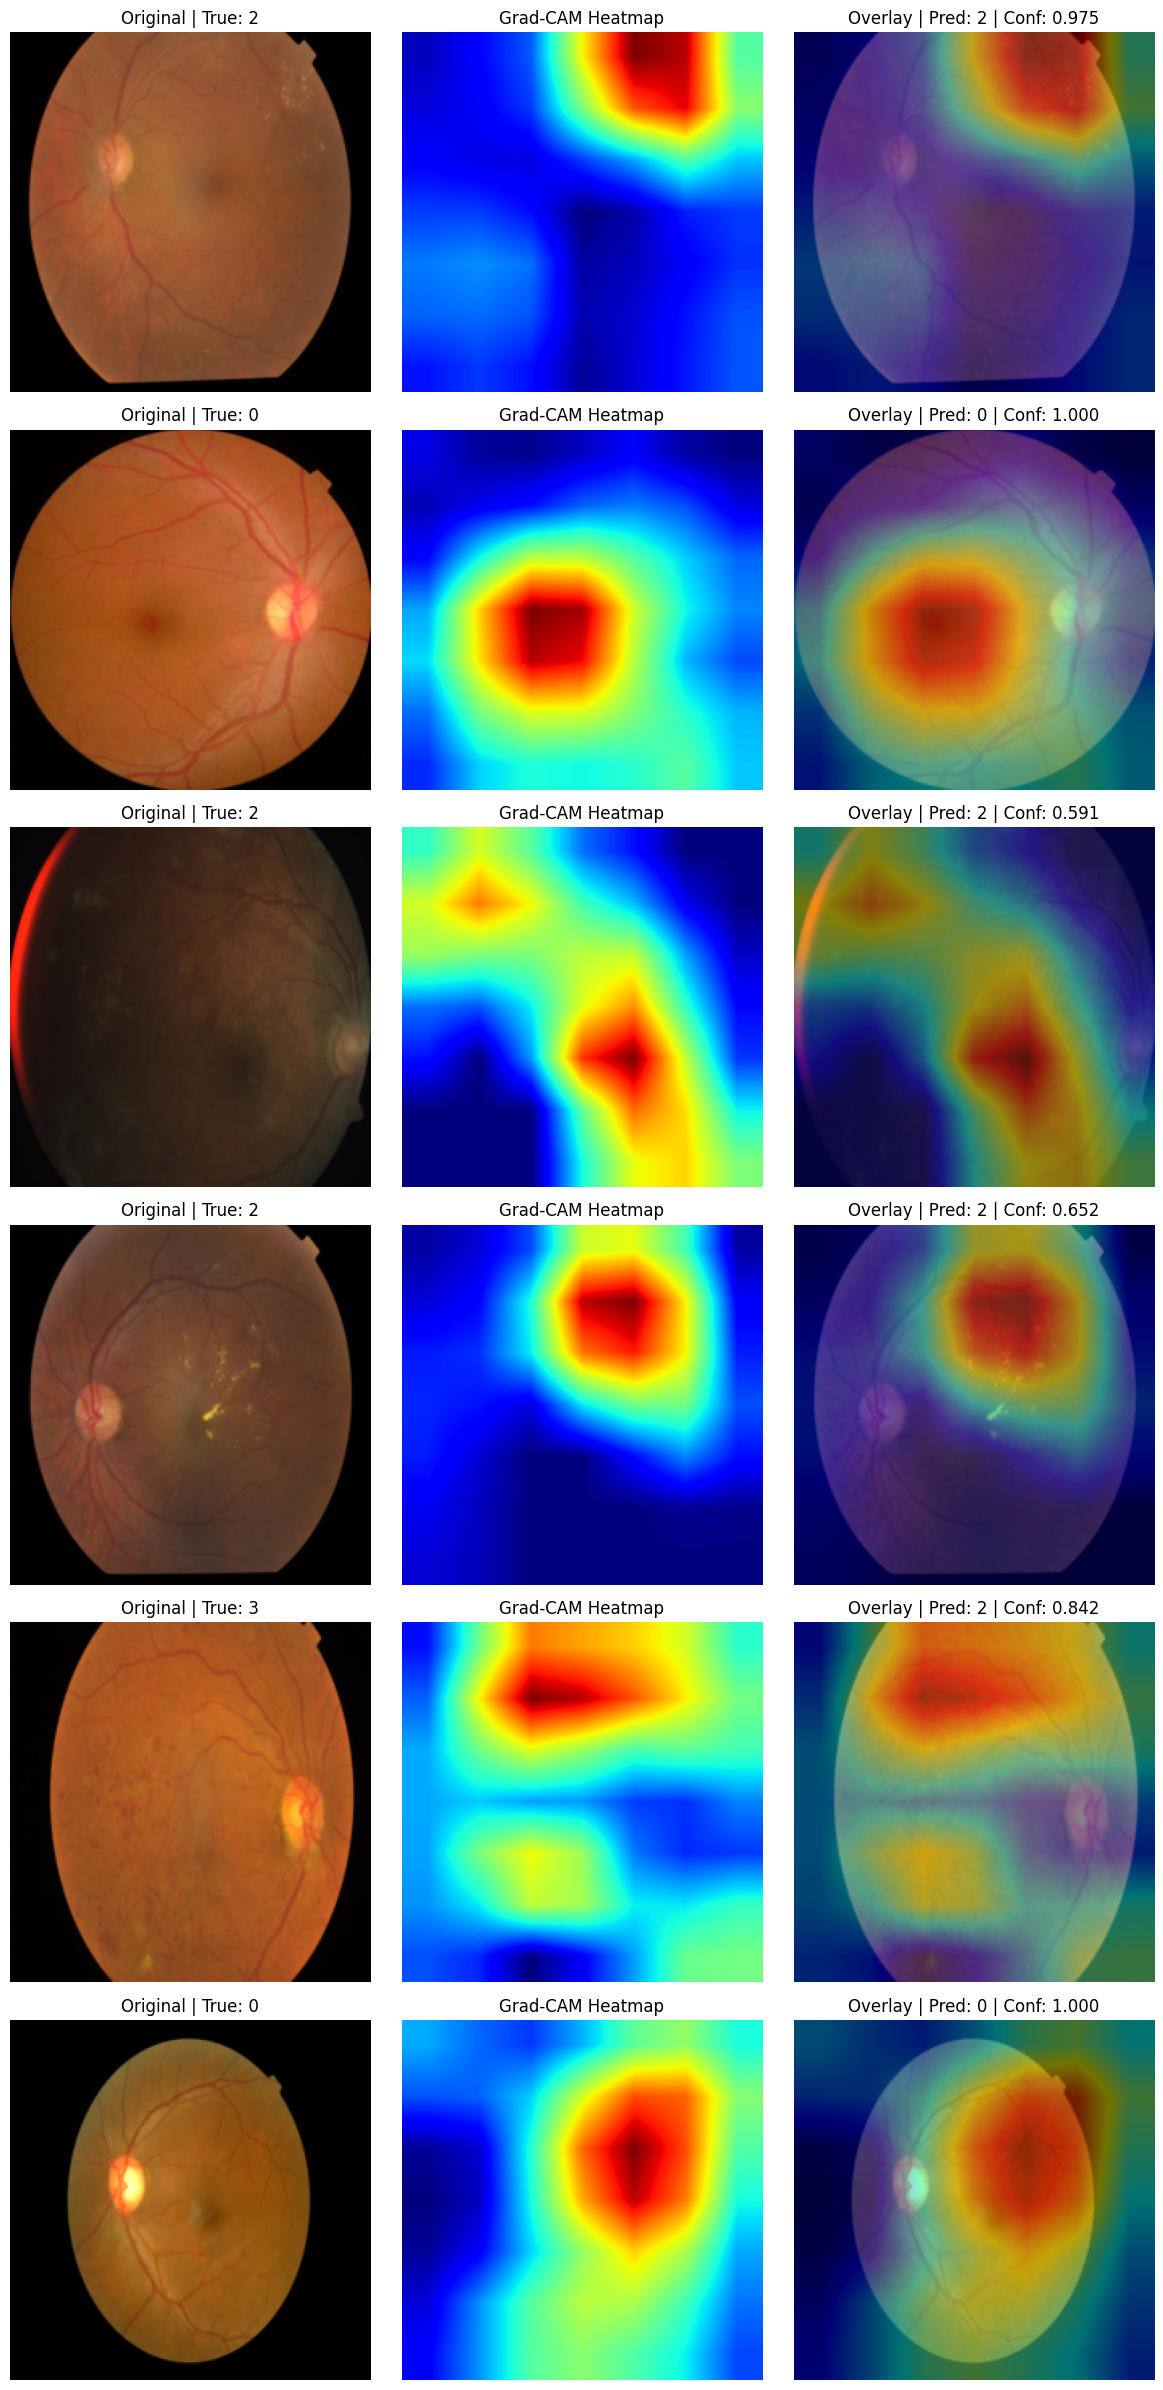

In [36]:
# =========================
# SHOW GRAD-CAM ON TEST IMAGES
# =========================
show_gradcam_samples(
    dataset=test_dataset,
    n_samples=6)